# 04 — `score_lr`: H1 vs H0 discrimination with two `Echo` instances

Train one `Echo` on each hypothesis (H0 and H1) and use
`Δχ²(x) = χ²_H0(x) − χ²_H1(x)`
as a per-event score. Sign convention (physics): `Δχ² > 0` → event more H1-like.

Under approximate joint Gaussianity in the whitened space, `Δχ² ≈ 2·log(L_H1/L_H0) + const`, so this is a proxy of the log-likelihood ratio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

from echo import Echo, score_lr
from echo.synthetic import make_sample


## 1. Two hypotheses

- **H0**: `x` normal(0, 1), `y` uniform(0, 1), `z` normal(0, 1), correlation 0.5.
- **H1**: `x` normal(1.5, 2), `y` uniform(-2, 3), `z` normal(-0.5, 0.5), correlation -0.2.

In [2]:
dists   = ['normal', 'uniform', 'normal']

params_h0, rho_h0 = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0)],     0.5
params_h1, rho_h1 = [(1.5, 2.0), (-2.0, 3.0), (-0.5, 0.5)], -0.2

h0_train = make_sample(20_000, dists, parameters=params_h0, correlation=rho_h0, seed=1)
h1_train = make_sample(20_000, dists, parameters=params_h1, correlation=rho_h1, seed=2)

echo_h0 = Echo(); echo_h0.train(h0_train)
echo_h1 = Echo(); echo_h1.train(h1_train)

print('Eigenvalues of each Echo (sorted desc):')
print('  echo_h0:', echo_h0._eigenvalues.round(3))
print('  echo_h1:', echo_h1._eigenvalues.round(3))


Eigenvalues of each Echo (sorted desc):
  echo_h0: [1.994 0.507 0.497]
  echo_h1: [1.205 1.189 0.603]


## 2. Test samples from each hypothesis

In [3]:
n_test     = 5_000
sample_h0  = make_sample(n_test, dists, parameters=params_h0, correlation=rho_h0, seed=10)
sample_h1  = make_sample(n_test, dists, parameters=params_h1, correlation=rho_h1, seed=11)

score_h0 = score_lr(echo_h1, echo_h0, sample_h0)
score_h1 = score_lr(echo_h1, echo_h0, sample_h1)

print('Δχ² summary:')
print(pd.DataFrame({
    'mean':   [score_h0.mean(),   score_h1.mean()],
    'median': [score_h0.median(), score_h1.median()],
    'std':    [score_h0.std(),    score_h1.std()],
}, index=['sample ~ H0', 'sample ~ H1']).round(3))


Δχ² summary:
               mean  median     std
sample ~ H0  -2.703  -1.404   4.757
sample ~ H1  27.379  26.496  14.915


## 3. Δχ² distribution per hypothesis

Two overlapping histograms. The more they separate, the easier H1 vs H0 discrimination.

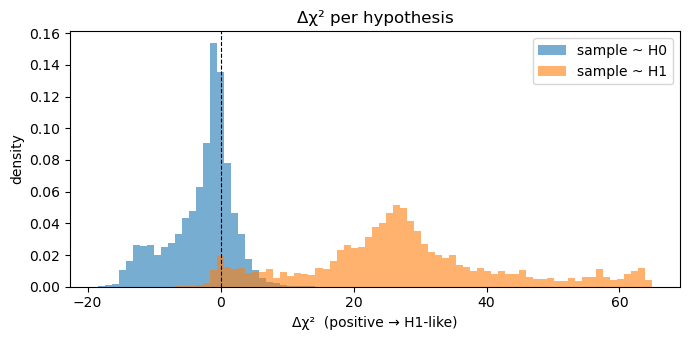

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(min(score_h0.min(), score_h1.min()), max(score_h0.max(), score_h1.max()), 80)
ax.hist(score_h0, bins=bins, alpha=0.6, density=True, label='sample ~ H0')
ax.hist(score_h1, bins=bins, alpha=0.6, density=True, label='sample ~ H1')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Δχ²  (positive → H1-like)')
ax.set_ylabel('density')
ax.legend()
ax.set_title('Δχ² per hypothesis')
fig.tight_layout()


## 4. ROC curve and AUC

Label H0 → 0, H1 → 1; score = `Δχ²`. ROC sweeps a threshold and shows the trade-off between true-positive (H1 correctly identified) and false-positive (H0 misclassified as H1).

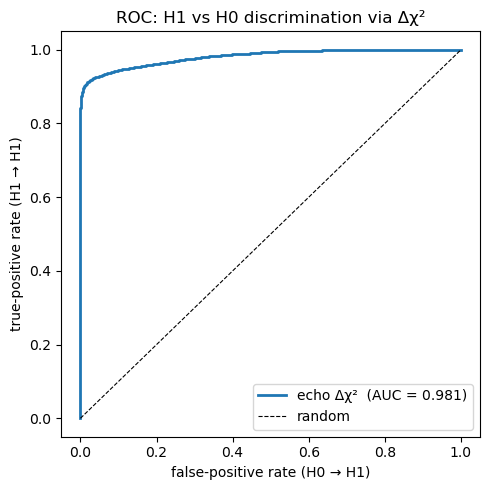

In [5]:
y_true = np.concatenate([np.zeros(len(score_h0)), np.ones(len(score_h1))])
y_pred = np.concatenate([score_h0.to_numpy(),     score_h1.to_numpy()])

fpr, tpr, _ = roc_curve(y_true, y_pred)
auc          = roc_auc_score(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2, label=f'echo Δχ²  (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='random')
ax.set_xlabel('false-positive rate (H0 → H1)')
ax.set_ylabel('true-positive rate (H1 → H1)')
ax.set_title('ROC: H1 vs H0 discrimination via Δχ²')
ax.legend(loc='lower right')
fig.tight_layout()


## 5. χ²_H0 vs χ²_H1 scatter

The score `Δχ²` is the difference of these two coordinates. Off-diagonal events are the most informative.

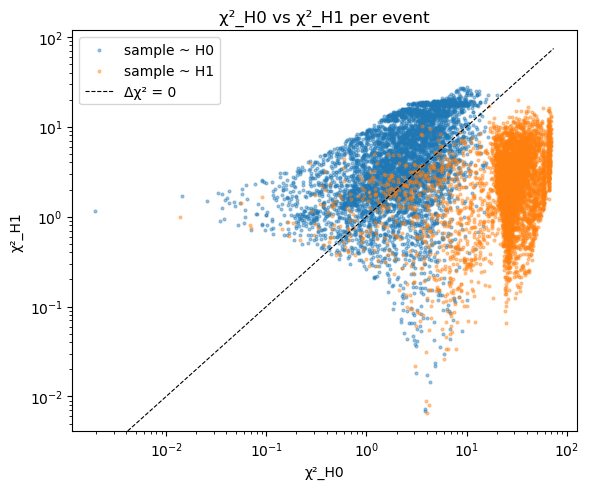

In [6]:
def chi2_pair(echo, sample):
    z, _ = echo.test(sample)
    return (z ** 2).sum(axis=1).to_numpy()

chi2_h0_on_s0 = chi2_pair(echo_h0, sample_h0)
chi2_h1_on_s0 = chi2_pair(echo_h1, sample_h0)
chi2_h0_on_s1 = chi2_pair(echo_h0, sample_h1)
chi2_h1_on_s1 = chi2_pair(echo_h1, sample_h1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(chi2_h0_on_s0, chi2_h1_on_s0, s=4, alpha=0.4, label='sample ~ H0')
ax.scatter(chi2_h0_on_s1, chi2_h1_on_s1, s=4, alpha=0.4, label='sample ~ H1')
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='Δχ² = 0')
ax.set_xlabel('χ²_H0')
ax.set_ylabel('χ²_H1')
ax.set_title('χ²_H0 vs χ²_H1 per event')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
fig.tight_layout()


## 6. Sensitivity: how separated must H1 be from H0?

Hold H0 fixed and parameterize H1 by a single "strength" parameter. Here we move only the mean of `x` (everything else equal to H0). For each value, retrain `echo_h1`, draw an H1 sample, and report AUC.

AUC vs shift:
0.000    0.5023
0.125    0.5510
0.250    0.5953
0.375    0.6375
0.500    0.6778
0.625    0.7160
0.750    0.7518
0.875    0.7851
1.000    0.8155
1.125    0.8430
1.250    0.8677
1.375    0.8895
1.500    0.9087
dtype: float64


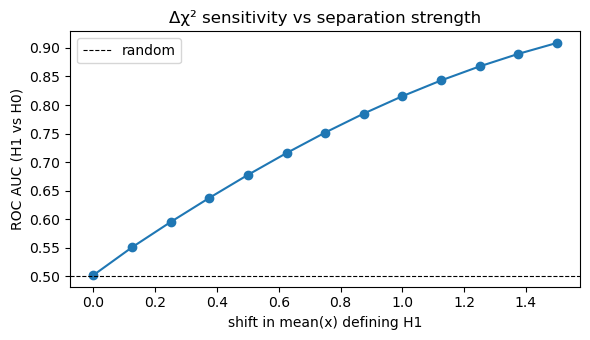

In [7]:
shifts = np.linspace(0.0, 1.5, 13)
aucs   = []

n_per  = 5_000

for delta in shifts:
    params_h1_local = [(delta, 1.0), (0.0, 1.0), (0.0, 1.0)]

    train_h1_local = make_sample(20_000, dists, parameters=params_h1_local, correlation=rho_h0, seed=100)
    echo_h1_local  = Echo(); echo_h1_local.train(train_h1_local)

    test_h0_local  = make_sample(n_per, dists, parameters=params_h0,        correlation=rho_h0, seed=200)
    test_h1_local  = make_sample(n_per, dists, parameters=params_h1_local,  correlation=rho_h0, seed=201)

    d0_local = score_lr(echo_h1_local, echo_h0, test_h0_local).to_numpy()
    d1_local = score_lr(echo_h1_local, echo_h0, test_h1_local).to_numpy()

    y    = np.concatenate([np.zeros(n_per), np.ones(n_per)])
    pred = np.concatenate([d0_local, d1_local])
    aucs.append(roc_auc_score(y, pred))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(shifts, aucs, 'o-')
ax.axhline(0.5, color='k', ls='--', lw=0.8, label='random')
ax.set_xlabel('shift in mean(x) defining H1')
ax.set_ylabel('ROC AUC (H1 vs H0)')
ax.set_title('Δχ² sensitivity vs separation strength')
ax.legend()
fig.tight_layout()

print('AUC vs shift:')
print(pd.Series(aucs, index=shifts.round(3)).round(4))
